
<h1 align="center">Workshop 2 - Bonus</h1>

<h2 align="center">Universidad Nacional de Colombia - Deep learning - 2024-II</h2>

<h3 align="center">Andres Calle - Arley Reina - Manuela Granda</h3>


Run the Jupyter notebook Yolo_Potholes in Collab, but this time using the &#39;yolov8n-seg.pt&#39;,
this is the YOLOv8 model pretrained for segmentation in the Pothole Dataset from Kaggle.
See the results and Create the video !

In [2]:
%pip install ultralytics -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from ultralytics import YOLO
import cv2
from PIL import Image
import yaml
import random

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
# Mount Google Drive
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Load and prepare data

In [5]:
# Paths
dataDir = "/content/drive/MyDrive/deep_learning/workshowp3/Pothole_Segmentation_YOLOv8/"  # Folder containing images

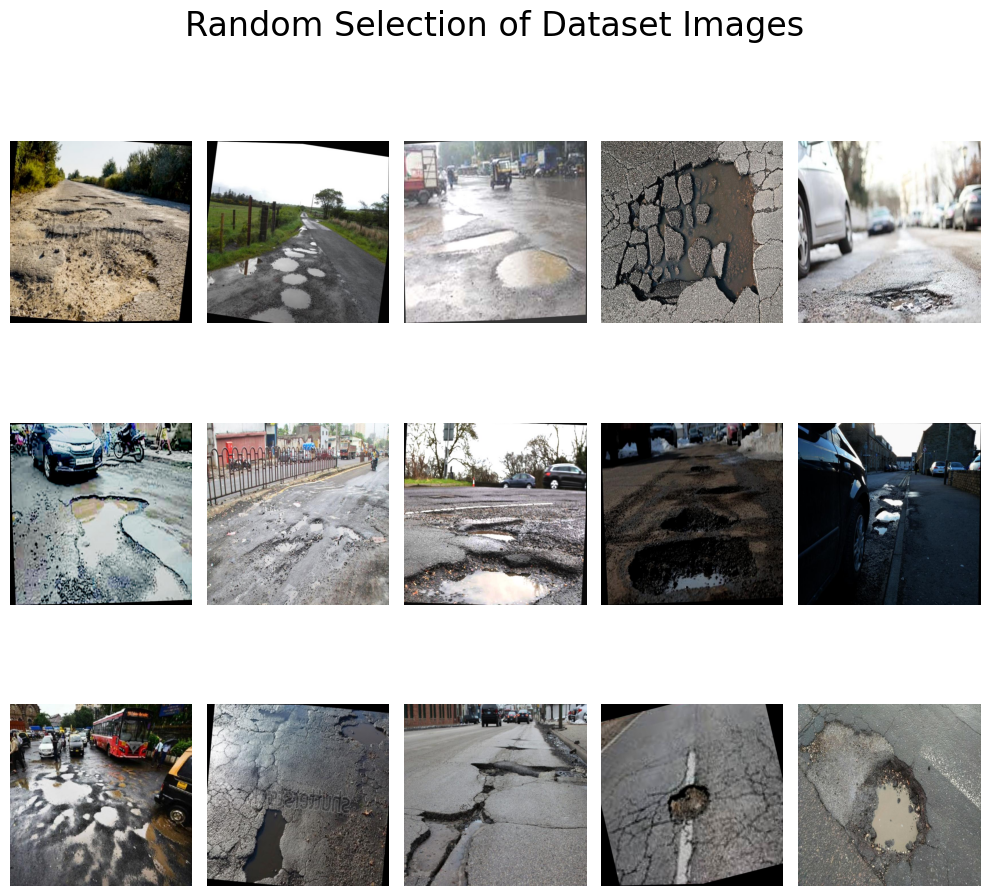

In [6]:
trainImagePath = os.path.join(dataDir, 'train','images')

#list of the images
imageFiles = [f for f in os.listdir(trainImagePath) if f.endswith('.jpg')]

randomImages = random.sample(imageFiles, 15)

plt.figure(figsize=(10, 10))

for i, image_file in enumerate(randomImages):

    image_path = os.path.join(trainImagePath, image_file)
    image = Image.open(image_path)
    plt.subplot(3, 5, i + 1)
    plt.imshow(image)
    plt.axis('off')

  # Add a suptitle
plt.suptitle('Random Selection of Dataset Images', fontsize=24)

# Show the plot
plt.tight_layout()
plt.show()

## Train the model

In [7]:
model = YOLO('yolov8n-seg.pt',) # for segmentation use 'yolov8n-seg.pt, change the model as you like !

100%|██████████| 6.74M/6.74M [00:00<00:00, 102MB/s]


In [8]:
yamlFilePath = os.path.join(dataDir,'data.yaml' )

In [9]:
results = model.train(
    data= yamlFilePath,
    epochs=5,
    imgsz=640,
    batch=32,
    optimizer='auto',
    lr0=0.0001,              # Initial learning rate
    lrf=0.01,                # Final learning rate (lr0 * lrf)
    dropout=0.25,            # Use dropout regularization
    device = 0,                # Device to run on, i.e. cuda device=0
    seed=42
)

Ultralytics 8.3.39 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=segment, mode=train, model=yolov8n-seg.pt, data=/content/drive/MyDrive/deep_learning/workshowp3/Pothole_Segmentation_YOLOv8/data.yaml, epochs=5, time=None, patience=100, batch=32, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.25, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False,

100%|██████████| 755k/755k [00:00<00:00, 20.2MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 83.8MB/s]


AMP: checks passed ✅


...

        5/5      5.39G      1.333      2.282      1.486      1.347         58        640: 100%|██████████| 23/23 [00:19<00:00,  1.20it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:01<00:00,  1.44s/it]

                   all         60        201      0.567      0.572      0.581      0.318      0.596      0.562      0.585      0.307



5 epochs completed in 0.036 hours.
Optimizer stripped from runs/segment/train/weights/last.pt, 6.8MB
Optimizer stripped from runs/segment/train/weights/best.pt, 6.8MB

Validating runs/segment/train/weights/best.pt...
Ultralytics 8.3.39 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8n-seg summary (fused): 195 layers, 3,258,259 parameters, 0 gradients, 12.0 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  1.15it/s]


                   all         60        201      0.574       0.57      0.581      0.318      0.596      0.562      0.582      0.308
Speed: 0.2ms preprocess, 3.0ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to runs/segment/train



image 1/1 /content/drive/MyDrive/deep_learning/workshowp3/Pothole_Segmentation_YOLOv8/valid/images/pic-114-_jpg.rf.a0f30e06b3b96d7879d5f55a7012433c.jpg: 640x640 2 Potholes, 17.0ms
Speed: 2.9ms preprocess, 17.0ms inference, 4.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/deep_learning/workshowp3/Pothole_Segmentation_YOLOv8/valid/images/pic-144-_jpg.rf.61a3b886f058ed3a4788426cfa7c4988.jpg: 640x640 3 Potholes, 15.8ms
Speed: 1.6ms preprocess, 15.8ms inference, 3.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/deep_learning/workshowp3/Pothole_Segmentation_YOLOv8/valid/images/pic-165-_jpg.rf.82b3db37518b15aa73be6e4093deaf46.jpg: 640x640 2 Potholes, 18.3ms
Speed: 1.6ms preprocess, 18.3ms inference, 3.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/deep_learning/workshowp3/Pothole_Segmentation_YOLOv8/valid/images/pic-184-_jpg.rf.cb753b5f714073fc4a8c2de602386399.jpg: 640x640 5 Po

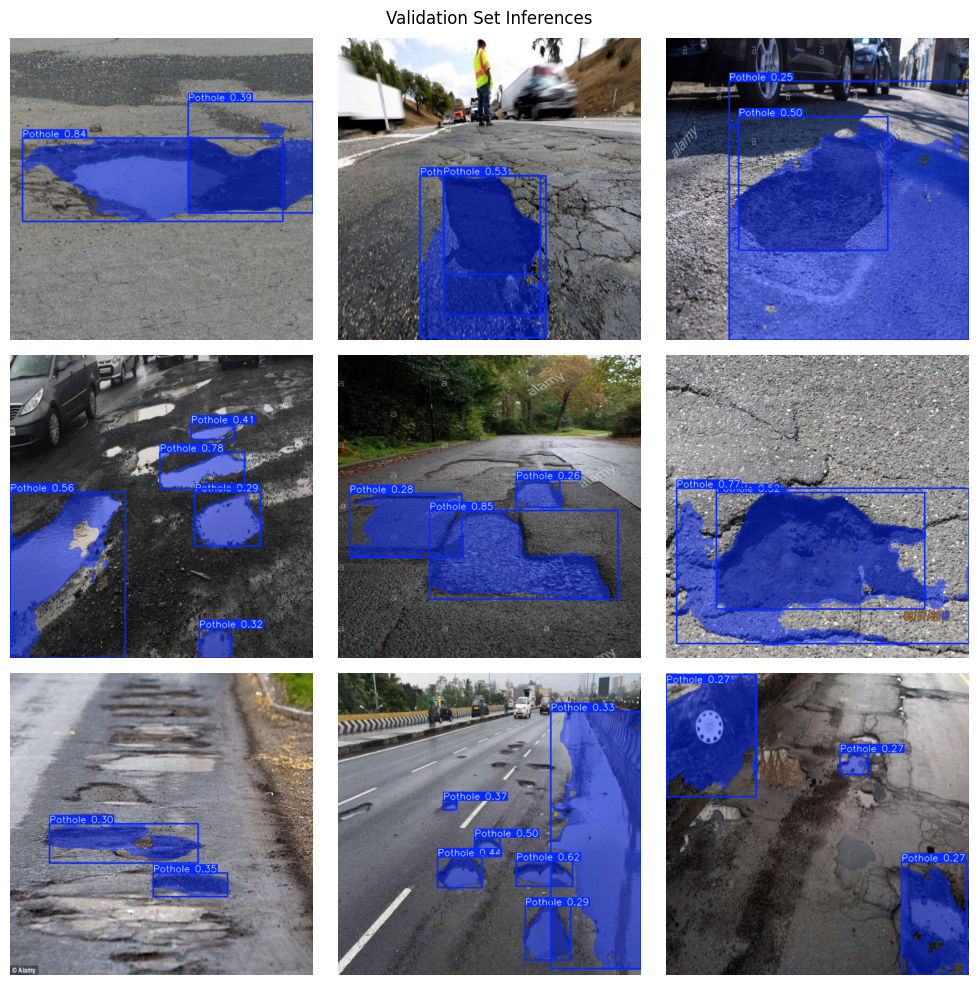

In [10]:
validImagePath = os.path.join(dataDir, 'valid', 'images')

imageFiles = [f for f in os.listdir(validImagePath) if f.endswith('.jpg')]

#select Random images
numImages = len(imageFiles)
selectedImage = [imageFiles[i] for i in range(0, numImages, numImages // 9)]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle('Validation Set Inferences')

for i, ax in enumerate(axes.flatten()):
  imagePath = os.path.join(validImagePath, selectedImage[i])
  results = model.predict(source= imagePath, imgsz=640)
  annotatedImage = results[0].plot()
  annotatedImageRGB = cv2.cvtColor(annotatedImage, cv2.COLOR_BGR2RGB)
  ax.imshow(annotatedImageRGB)
  ax.axis('off')

plt.tight_layout()
plt.show()

Make the Inference video

In [12]:
# Change the model for the best model and do everything again and compare

bestModelpath = '/content/runs/segment/train/weights/best.pt'
bestModel = YOLO(bestModelpath)

In [14]:
import shutil
videoPath = '/content/drive/MyDrive/deep_learning/workshowp3/Pothole_Segmentation_YOLOv8/sample_video.mp4'

model.predict(source=videoPath, save=True, verbose=False)


WARNING ⚠️ inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to runs/segment/train2


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: 'Pothole'}
 obb: None
 orig_img: array([[[146, 137, 129],
         [177, 168, 160],
         [178, 169, 161],
         ...,
         [246, 243, 244],
         [246, 243, 244],
         [246, 243, 244]],
 
        [[197, 188, 180],
         [206, 197, 189],
         [164, 155, 147],
         ...,
         [246, 243, 244],
         [246, 243, 244],
         [246, 243, 244]],
 
        [[150, 141, 133],
         [183, 174, 166],
         [188, 179, 171],
         ...,
         [246, 243, 244],
         [246, 243, 244],
         [246, 243, 244]],
 
        ...,
 
        [[ 80,  92, 102],
         [ 70,  82,  92],
         [ 63,  75,  85],
         ...,
         [ 61,  81, 101],
         [ 62,  82, 102],
         [ 65,  85, 105]],
 
        [[ 70,  82,  92],
         [ 63,  75,  85],
         [ 59,  71,  8

## Conclusions

- From the training it can be seen that some of the validation images do not recognize some holes well, particularly with those that are too many or have other objects in the image.

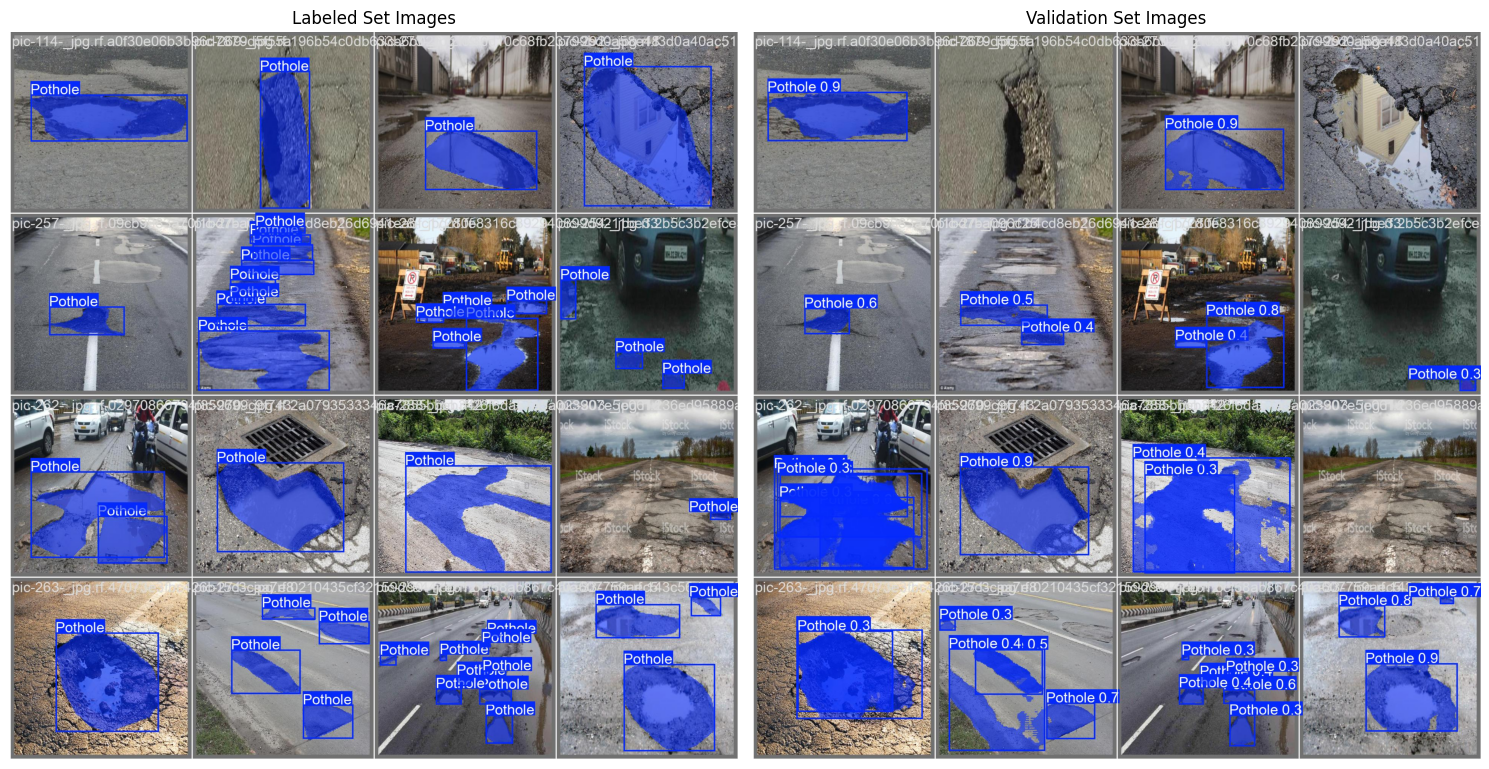

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
paths_comparative = ['/content/runs/segment/train/val_batch0_labels.jpg',
                     '/content/runs/segment/train/val_batch0_pred.jpg']
for i, path in enumerate(paths_comparative):
        image = Image.open(path)

        axes[i].imshow(image)
        axes[i].axis('off')

axes[0].set_title('Labeled Set Images')
axes[1].set_title('Validation Set Images')
plt.tight_layout()
plt.show()

- From the training curves it can be seen that the metrics of F1 confidence and Precision Recall are not very good (area under the curve should be 1), probably more epochs would have been necessary to achieve better results.

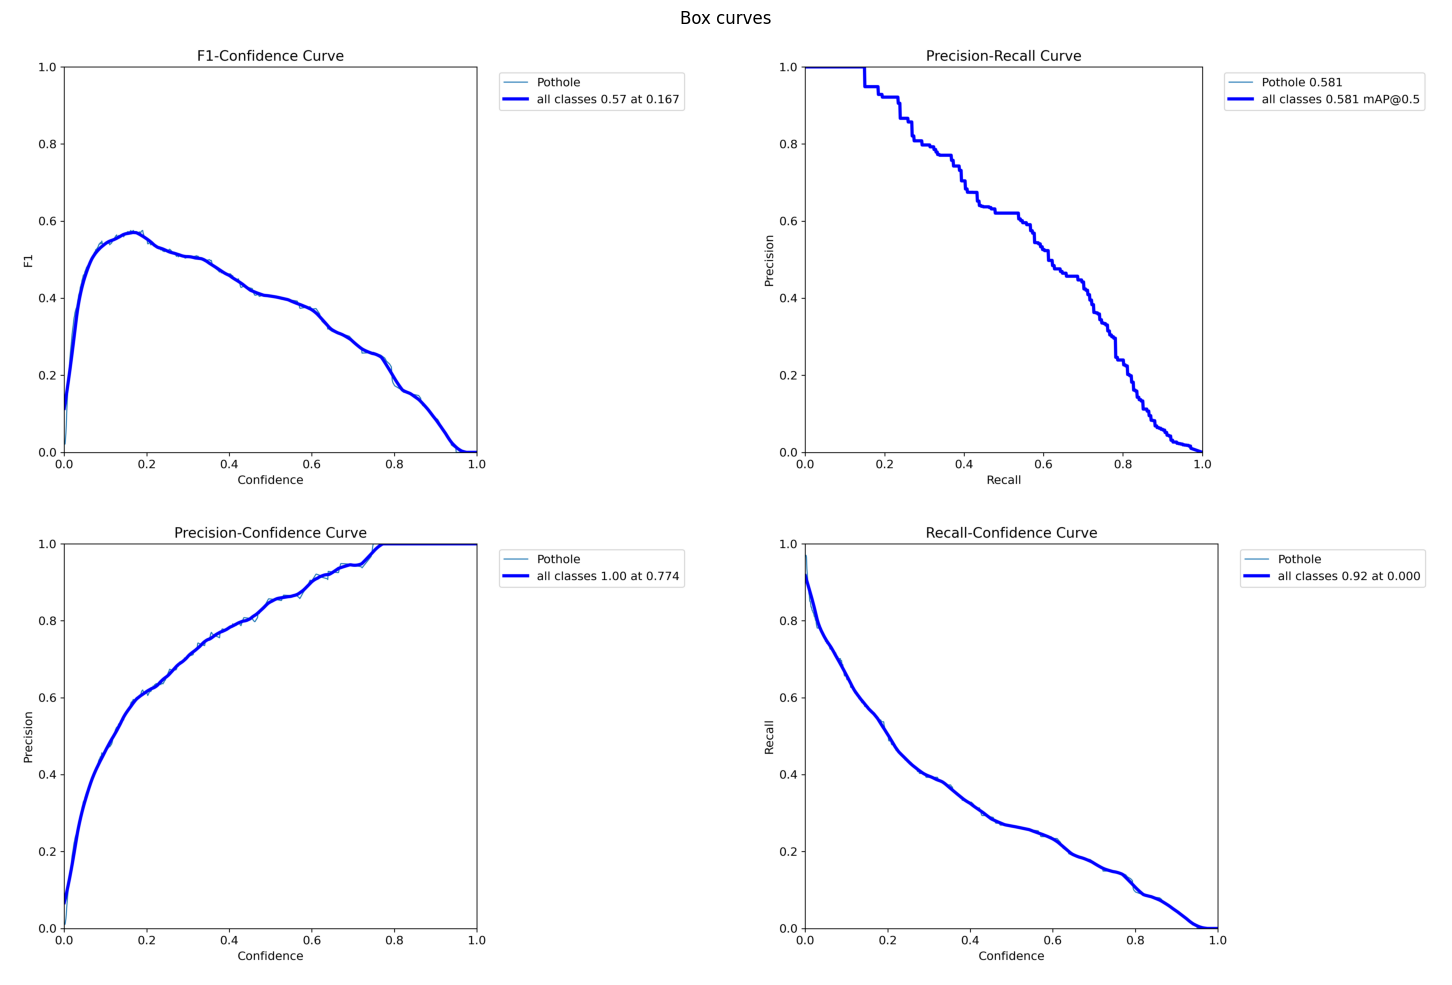

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
paths_comparative = ['/content/runs/segment/train/BoxF1_curve.png',
                     '/content/runs/segment/train/BoxPR_curve.png',
                    '/content/runs/segment/train/BoxP_curve.png',
                    '/content/runs/segment/train/BoxR_curve.png']

num_images = len(paths_comparative)

axes = axes.flatten() if num_images > 1 else [axes]

for i, path in enumerate(paths_comparative):
        image = Image.open(path)
        axes[i].imshow(image)
        axes[i].axis('off')

# Add a global title with adjusted position and font size
plt.suptitle('Box curves')
plt.tight_layout()
plt.show()

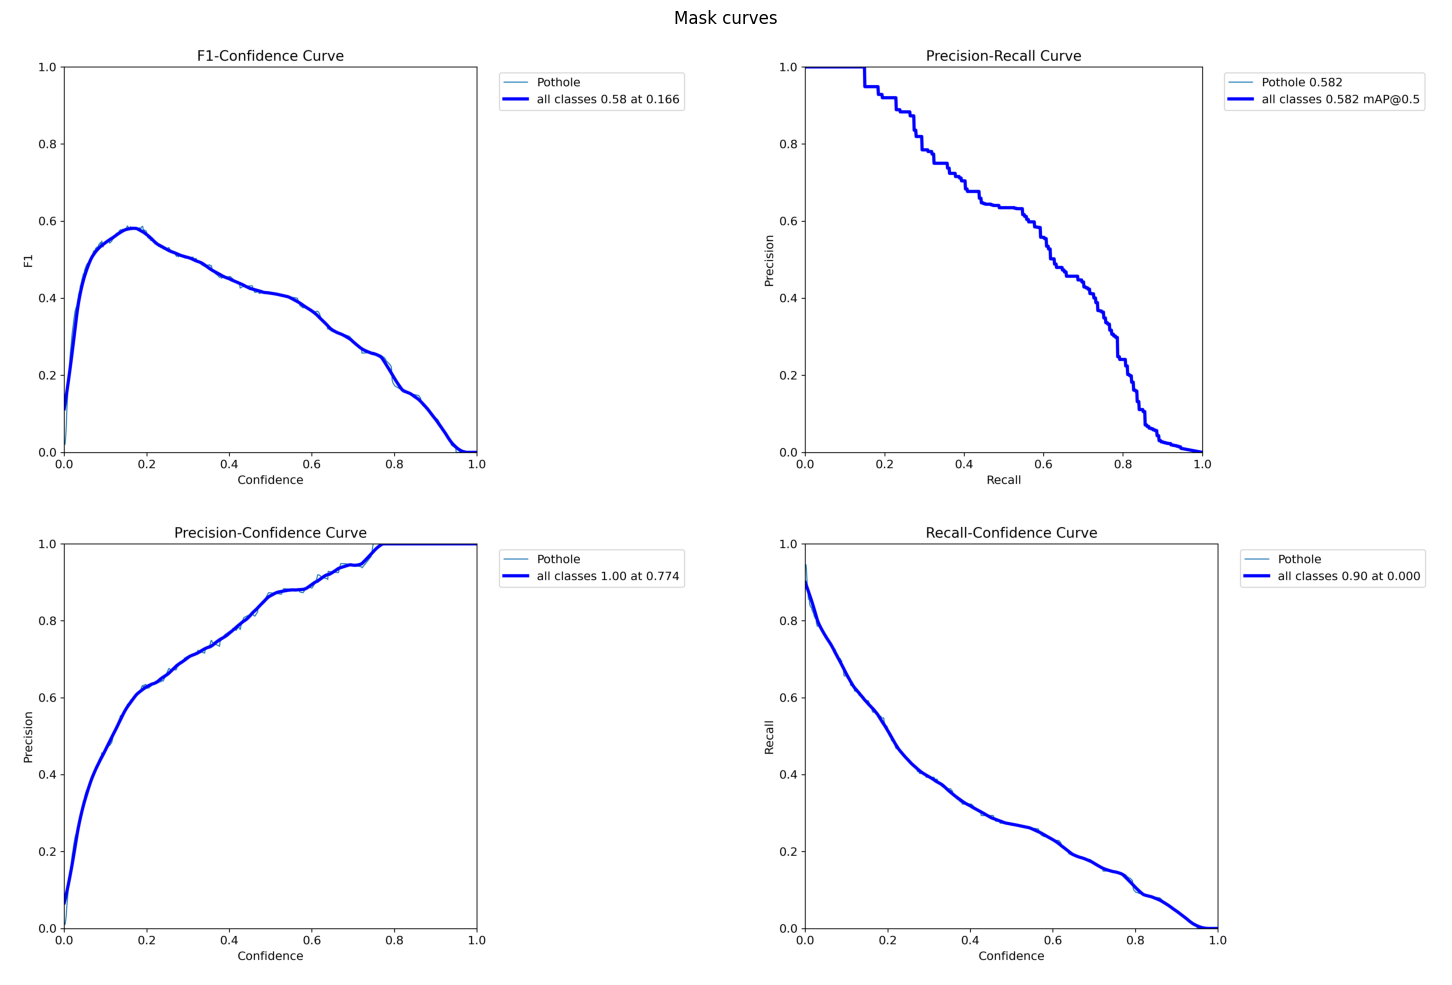

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
paths_comparative = ['/content/runs/segment/train/MaskF1_curve.png',
                     '/content/runs/segment/train/MaskPR_curve.png',
                    '/content/runs/segment/train/MaskP_curve.png',
                    '/content/runs/segment/train/MaskR_curve.png']

num_images = len(paths_comparative)

axes = axes.flatten() if num_images > 1 else [axes]

for i, path in enumerate(paths_comparative):
        image = Image.open(path)
        axes[i].imshow(image)
        axes[i].axis('off')
plt.suptitle('Mask curves')
plt.tight_layout()
plt.show()

It can also be seen from the confusion matrices that many of the holes are confused with the background of the image which explains the learning curves.

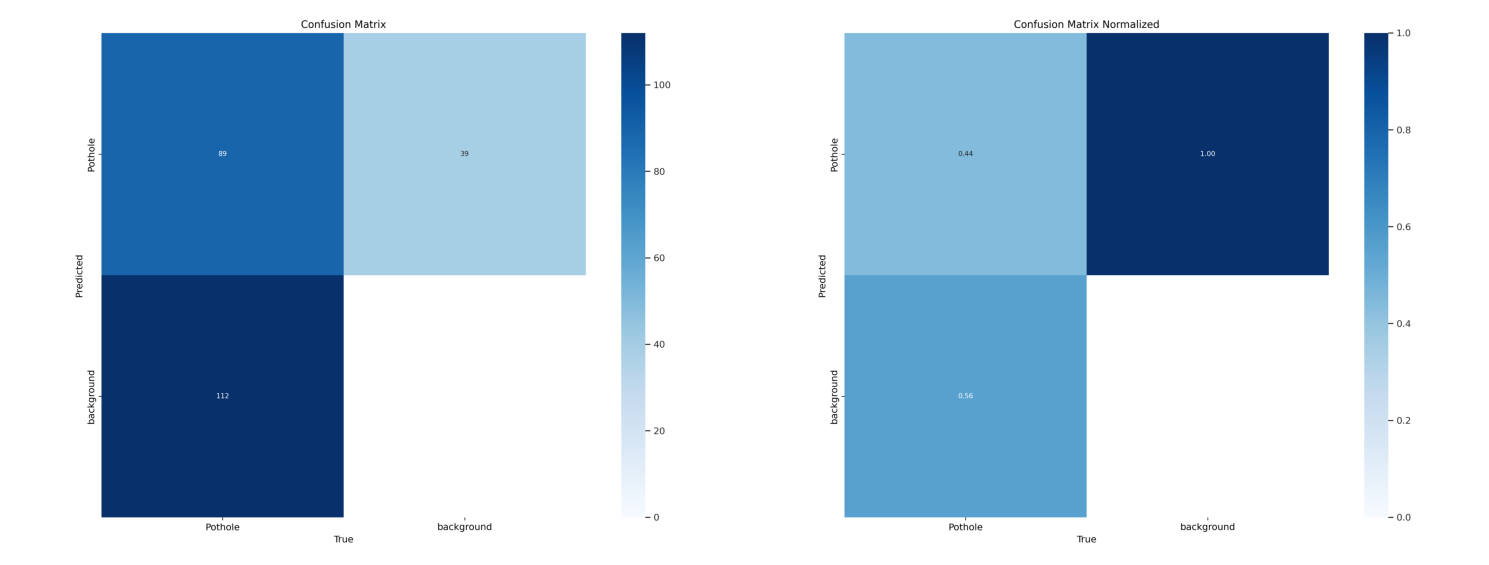

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
paths_comparative = ['/content/runs/segment/train/confusion_matrix.png',
                     '/content/runs/segment/train/confusion_matrix_normalized.png']
for i, path in enumerate(paths_comparative):
        image = Image.open(path)

        axes[i].imshow(image)
        axes[i].axis('off')


plt.tight_layout()
plt.show()

## Save result

In [27]:
import shutil
from IPython.display import FileLink

# Path to the folder you want to zip
folder_path = '/content/runs/segment'

# Output zip file path
zip_path = '/content/result_pothole_segmentation.zip'

# Create the zip archive
shutil.make_archive(zip_path.replace('.zip', ''), 'zip', folder_path)

# Display the download link
FileLink(zip_path)

/content/result_pothole_segmentation.zip